# Feature Selection 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Processed Data

In [2]:
# Load processed data
train = pd.read_csv('../data/processed/train_processed.csv')
test = pd.read_csv('../data/processed/test_processed.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (20804, 40)
Test shape: (4750, 38)


## 2. Correlation Analysis

Finding highly correlated feature pairs (threshold > 0.70).

In [3]:
# Calculate correlation matrix
numeric_data = train.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

# Find high correlations
def get_high_correlations(corr_matrix, threshold=0.7):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    stacked_corr = upper_tri.stack().sort_values(ascending=False)
    
    print(f"Correlations above {threshold}:\n")
    for (col1, col2), val in stacked_corr.items():
        if abs(val) > threshold:
            print(f"{col1} - {col2}: {val:.4f}")

get_high_correlations(corr_matrix, threshold=0.70)

Correlations above 0.7:

calculated_host_listings_count - calculated_host_listings_count_entire_homes: 0.9980
host_listings_count - calculated_host_listings_count: 0.9860
host_listings_count - calculated_host_listings_count_entire_homes: 0.9839
review_scores_rating - review_scores_value: 0.9093
review_scores_rating - review_scores_accuracy: 0.9082
host_listings_count - host_total_listings_count: 0.9003
review_scores_rating - review_scores_cleanliness: 0.8806
review_scores_accuracy - review_scores_value: 0.8796
review_scores_checkin - review_scores_communication: 0.8528
review_scores_accuracy - review_scores_cleanliness: 0.8491
review_scores_cleanliness - review_scores_value: 0.8461
property_type - room_type: 0.8442
host_total_listings_count - calculated_host_listings_count: 0.8437
host_total_listings_count - calculated_host_listings_count_entire_homes: 0.8421
review_scores_rating - review_scores_communication: 0.8416
review_scores_accuracy - review_scores_communication: 0.8250
review_s

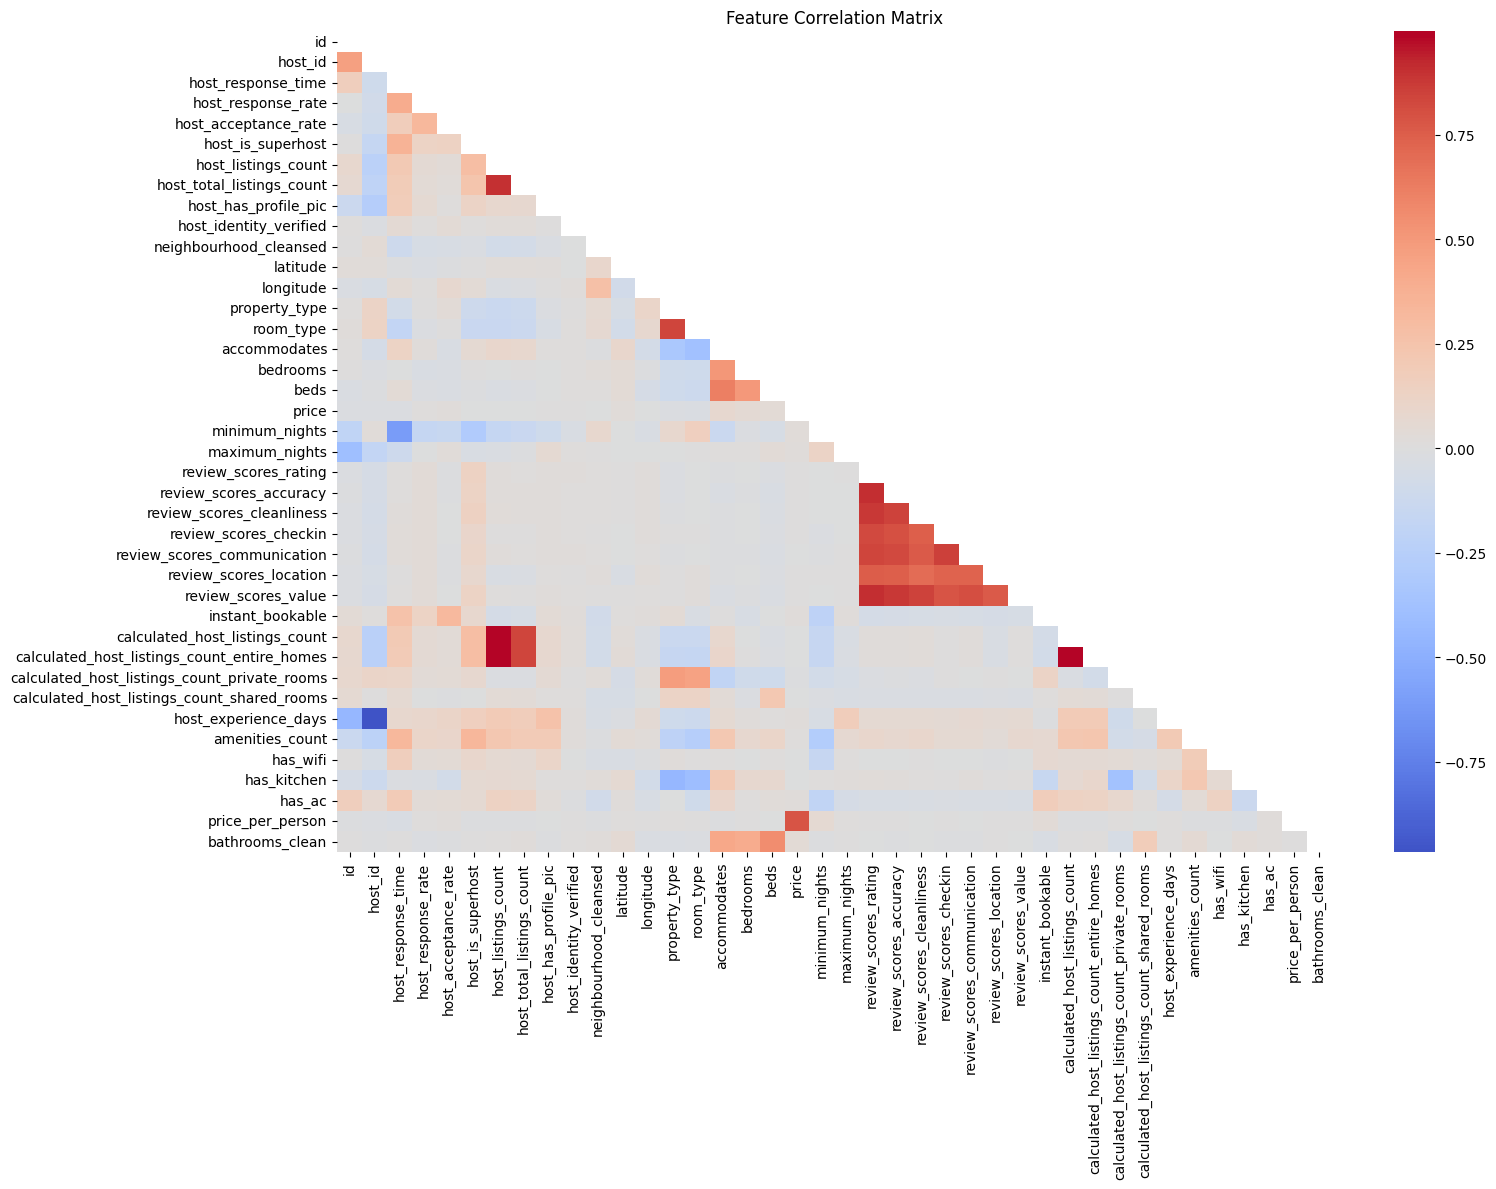

In [4]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Remove Highly Correlated Features

Dropping features with correlation > 0.85 to reduce multicollinearity.

In [5]:
# Find columns to drop (correlation > 0.85)
corr_abs = numeric_data.corr().abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Columns to drop: {to_drop}")
print(f"Number of columns to drop: {len(to_drop)}")

Columns to drop: ['host_total_listings_count', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'host_experience_days']
Number of columns to drop: 8


In [6]:
# Drop highly correlated columns
train_clean = train.drop(columns=to_drop)
test_clean = test.drop(columns=[col for col in to_drop if col in test.columns])

# Also drop price_per_person from train if exists (not in test)
if 'price_per_person' in train_clean.columns:
    train_clean = train_clean.drop(columns=['price_per_person'])

print(f"Train shape after: {train_clean.shape}")
print(f"Test shape after: {test_clean.shape}")

Train shape after: (20804, 31)
Test shape after: (4750, 30)


## 4. Save Updated Data

In [7]:
# Save updated data
train_clean.to_csv('../data/processed/train_final.csv', index=False)
test_clean.to_csv('../data/processed/test_final.csv', index=False)

print("Data saved successfully!")
print(f"Final train shape: {train_clean.shape}")
print(f"Final test shape: {test_clean.shape}")

Data saved successfully!
Final train shape: (20804, 31)
Final test shape: (4750, 30)


## Summary

| Step | Before | After |
|------|--------|-------|
| Train columns | 40 | 31 |
| Test columns | 38 | 30 |
| Dropped | 9 highly correlated features | - |

Multicollinearity reduced, data ready for modeling.